In [142]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [143]:
#Dataset loading
botnet=pd.read_csv("CIC-IDS2017-Dataset/Botnet-Friday-no-metadata.parquet.csv")
brute_force=pd.read_csv("CIC-IDS2017-Dataset/Bruteforce-Tuesday-no-metadata.parquet.csv")
ddos=pd.read_csv("CIC-IDS2017-Dataset/DDoS-Friday-no-metadata.parquet.csv")
dos=pd.read_csv("CIC-IDS2017-Dataset/DoS-Wednesday-no-metadata.parquet.csv")
infiltration=pd.read_csv("CIC-IDS2017-Dataset/Infiltration-Thursday-no-metadata.parquet.csv")
portscan=pd.read_csv("CIC-IDS2017-Dataset/Portscan-Friday-no-metadata.parquet.csv")
web_attack=pd.read_csv("CIC-IDS2017-Dataset/WebAttacks-Thursday-no-metadata.parquet.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [144]:
#Checking whether datasets have the same columns or not
datasets = {
    "Botnet":botnet,
    "DoS":dos,
    "DDoS":ddos,
    "Infiltration":infiltration,
    "Web Attack":web_attack,
    "Brute Force":brute_force,
    "PortScan":portscan
}

reference_columns = botnet.columns

for name, df in datasets.items():
    if reference_columns.equals(df.columns):
        print(f"{name}: Columns Match")
    else:
        print(f"{name}: Columns Do NOT Match")

Botnet: Columns Match
DoS: Columns Match
DDoS: Columns Match
Infiltration: Columns Match
Web Attack: Columns Match
Brute Force: Columns Match
PortScan: Columns Match


In [145]:
#Creating Master Dataset
master_df = pd.concat(
    [
        botnet,
        dos,
        ddos,
        infiltration,
        web_attack,
        brute_force,
        portscan
    ],
    axis=0,
    ignore_index=True
)
print("Master Dataset Created Successfully!")

Master Dataset Created Successfully!


In [146]:
# Shape of the master dataset
df = master_df.copy()

print(df.shape)
print(df["Label"].value_counts())

(1854979, 78)
Label
Benign                        1518487
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [190]:
temp = pd.DataFrame({
    "True_Label": y_test.reset_index(drop=True),
    "Prediction": predictions
})

label_mapping = {
    "Benign": "Benign",

    "Bot": "Botnet",

    "DDoS": "DDoS",

    "DoS Hulk": "DoS",
    "DoS GoldenEye": "DoS",
    "DoS Slowhttptest": "DoS",
    "DoS slowloris": "DoS",

    "FTP-Patator": "Brute Force",
    "SSH-Patator": "Brute Force",

    "Web Attack � Brute Force": "Web Attack",
    "Web Attack � Sql Injection": "Web Attack",
    "Web Attack � XSS": "Web Attack",

    "PortScan": "PortScan",

    "Infiltration": "Infiltration",

    "Heartbleed": "Heartbleed"
}

temp["True_Label"] = temp["True_Label"].map(label_mapping)

print(pd.crosstab(temp["True_Label"], temp["Prediction"]))

Prediction       -1       1
True_Label                 
Benign        68285  387261
Botnet           59     372
Brute Force     885    1860
DDoS          24385   14019
DoS           48557    9567
Heartbleed        3       0
Infiltration      1      10
PortScan         61     526
Web Attack       41     602


In [191]:
#Checking missing values
master_df.isnull().sum()

Protocol                    0
Flow Duration               0
Total Fwd Packets           0
Total Backward Packets      0
Fwd Packets Length Total    0
                           ..
Idle Mean                   0
Idle Std                    0
Idle Max                    0
Idle Min                    0
Label                       0
Length: 78, dtype: int64

In [192]:
# Checking attack distribution
master_df['Label'].value_counts()

Label
Benign                        1518487
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [193]:
print(df.columns.tolist())

['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ra

In [194]:
#Feature Enginnering
# Replace negative Flow Duration values with 0
df['Flow Duration'] = df['Flow Duration'].clip(lower=0)

In [195]:
 #Creating log flow duration 
df['Log_Flow_Duration'] = np.log1p(df['Flow Duration'])
print("Log_Flow_Duration created successfully!")

Log_Flow_Duration created successfully!


In [196]:
# Compare original and transformed values
df[['Flow Duration', 'Log_Flow_Duration']].head()

,Flow Duration,Log_Flow_Duration
0,112740690,18.540601
1,112740560,18.540600
2,113757377,18.549578
3,100126,11.514195
4,54760,10.910734


In [197]:
# Creating Forward Inter-Arrival Time Mean
df['Log_Fwd_IAT_Mean'] = np.log1p(df['Fwd IAT Mean'])
print("Log_Fwd_IAT_Mean created successfully!")

Log_Fwd_IAT_Mean created successfully!


In [198]:
# Compare original and transformed values
df[['Fwd IAT Mean', 'Log_Fwd_IAT_Mean']].head()

,Fwd IAT Mean,Log_Fwd_IAT_Mean
0,3636796.500,15.106614
1,3636792.200,15.106613
2,209112.830,12.250634
3,4767.905,8.469872
4,18253.334,9.812158


In [199]:


# Create Interaction_Density
df['Interaction_Density'] = (
    df['Total Fwd Packets'] +
    df['Total Backward Packets']
) / (df['Flow Duration'] + 1)
print("Interaction_Density created successfully!")

Interaction_Density created successfully!


In [200]:
#Verifying
df[['Total Fwd Packets',
    'Total Backward Packets',
    'Flow Duration',
    'Interaction_Density']].head()

,Total Fwd Packets,Total Backward Packets,Flow Duration,Interaction_Density
0,32,16,112740690,4.257558e-07
1,32,16,112740560,4.257563e-07
2,545,0,113757377,4.790898e-06
3,22,0,100126,2.197210e-04
4,4,0,54760,7.304469e-05


In [201]:
# Create Size_Symmetry
df['Size_Symmetry'] = (
    np.minimum(
        df['Fwd Packets Length Total'],
        df['Bwd Packets Length Total']
    )
    /
    (
        np.maximum(
            df['Fwd Packets Length Total'],
            df['Bwd Packets Length Total']
        ) + 1
    )
)
print("Size_Symmetry created successfully!")

Size_Symmetry created successfully!


In [202]:
#Verifying 
df[['Fwd Packets Length Total',
    'Bwd Packets Length Total',
    'Size_Symmetry']].head()

,Fwd Packets Length Total,Bwd Packets Length Total,Size_Symmetry
0,6448,1152,0.178632
1,6448,5056,0.783998
2,0,0,0.000000
3,616,0,0.000000
4,0,0,0.000000


In [203]:
#Importing standardScaler 
from sklearn.preprocessing import StandardScaler

In [204]:
#Selecting final features
features = [
    'Protocol',
    'Bwd Packet Length Max',
    'Log_Flow_Duration',
    'Log_Fwd_IAT_Mean',
    'Interaction_Density',
    'Size_Symmetry'
]
X = df[features]

In [205]:
# Check for Invalid Values
print("Missing Values:")
print(X.isnull().sum())
print("\nInfinite Values:")
print(np.isinf(X).sum())

Missing Values:
Protocol                 0
Bwd Packet Length Max    0
Log_Flow_Duration        0
Log_Fwd_IAT_Mean         0
Interaction_Density      0
Size_Symmetry            0
dtype: int64

Infinite Values:
Protocol                 0
Bwd Packet Length Max    0
Log_Flow_Duration        0
Log_Fwd_IAT_Mean         0
Interaction_Density      0
Size_Symmetry            0
dtype: int64


In [206]:
# Standardize the Features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)
print("Features standardized successfully!")
X_scaled.head()

Features standardized successfully!


,Protocol,Bwd Packet Length Max,Log_Flow_Duration,Log_Fwd_IAT_Mean,Interaction_Density,Size_Symmetry
0,-0.811890,-0.497114,1.406070,1.210788,-0.201444,-0.358232
1,-0.811890,-0.390612,1.406070,1.210788,-0.201444,1.818516
2,-1.924945,-0.528541,1.407879,0.769031,-0.201388,-1.000551
3,1.228711,-0.528541,-0.009570,0.184231,-0.198678,-1.000551
4,-1.924945,-0.528541,-0.131152,0.391853,-0.200528,-1.000551


In [207]:
print(df.shape)

(1854979, 82)


In [208]:
print(df["Label"].value_counts())

Label
Benign                        1518487
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [209]:
#Constructing Master Benign Gateway
#Creating the 70% Global Training pool
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    df["Label"],
    test_size=0.30,
    random_state=42,
    stratify=df["Label"]
)
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (1298485, 6)
Testing Set Shape: (556494, 6)


In [210]:
#Purging All 7 Malicious Footprints
X_train_benign = X_train[y_train == "Benign"]
print("Master Benign Dataset Shape:", X_train_benign.shape)

Master Benign Dataset Shape: (1062941, 6)


In [211]:
#Training the forest topology
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.10,
    max_samples="auto",
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_benign)
print("Isolation Forest trained successfully!")

Isolation Forest trained successfully!


In [169]:
#Test Stream & Isolation Physics
# Phase 5: Opening the Testing Vault
print("Testing Set Shape:", X_test.shape)

Testing Set Shape: (556494, 6)


In [170]:
print(type(y_test))
print(type(predictions))

print(y_test.shape)
print(len(predictions))

<class 'pandas.Series'>
<class 'numpy.ndarray'>
(556494,)
556494


In [171]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1298485, 6)
(556494, 6)
(1298485,)
(556494,)


In [172]:
print(len(predictions))
print(X_test.shape)

556494
(556494, 6)


In [173]:
print(predictions[:5])
print(len(predictions))

[ 1  1  1  1 -1]
556494


In [174]:
%who

IsolationForest	 StandardScaler	 X	 X_scaled	 X_test	 X_train	 X_train_benign	 X_vis	 Z	 
accuracy	 accuracy_score	 anomaly_scores	 attack	 auc	 botnet	 brute_force	 bruteforce	 c	 
classification_report	 cm	 confusion_matrix	 contamination_values	 datasets	 ddos	 detected	 df	 dos	 
features	 fpr	 infiltration	 iso	 iso_forest	 iso_vis	 label_mapping	 master_df	 name	 
np	 pd	 plt	 portscan	 predictions	 reference_columns	 results	 roc_auc_score	 roc_curve	 
scaler	 scores	 sns	 table	 temp	 thresholds	 total	 tpr	 train_test_split	 
web_attack	 webattack	 xx	 y_test	 y_test_binary	 y_train	 y_true	 yy	 


In [175]:
print("X_test shape:", X_test.shape)

predictions = iso_forest.predict(X_test)

print("Predictions:", len(predictions))

X_test shape: (556494, 6)


Predictions: 556494


In [176]:
temp = pd.DataFrame({
    "True_Label": y_test.reset_index(drop=True),
    "Prediction": predictions
})

print(pd.crosstab(temp["True_Label"], temp["Prediction"]))

Prediction                     -1       1
True_Label                               
Benign                      45582  409964
Bot                            36     395
DDoS                        24226   14178
DoS GoldenEye                1605    1481
DoS Hulk                    46379    5475
DoS Slowhttptest               79    1489
DoS slowloris                  22    1594
FTP-Patator                     5    1774
Heartbleed                      3       0
Infiltration                    0      11
PortScan                       52     535
SSH-Patator                     2     964
Web Attack � Brute Force       12     429
Web Attack � Sql Injection      0       6
Web Attack � XSS                3     193


In [177]:
# Appending the Security Status
results = X_test.copy()
results["Prediction"] = predictions
results.head()

,Protocol,Bwd Packet Length Max,Log_Flow_Duration,Log_Fwd_IAT_Mean,Interaction_Density,Size_Symmetry,Prediction
1317076,1.228711,-0.418110,-1.134189,-0.911442,-0.067647,-0.589201,1
1466768,1.228711,-0.460886,-0.164219,-1.125871,-0.200906,0.682081,1
1321168,1.228711,-0.494059,-1.303124,-1.125871,0.108020,0.446799,1
754677,1.228711,-0.507590,-1.314567,-1.018656,0.126105,1.371909,1
286098,-0.811890,1.367556,1.348853,1.396726,-0.201447,-0.892331,-1


In [178]:
# Count predicted classes
results["Prediction"].value_counts()

Prediction
 1    438488
-1    118006
Name: count, dtype: int64

In [179]:
# Matrix Validation
# Convert Actual Labels
y_test_binary = y_test.apply(
    lambda x: 1 if x == "Benign" else -1
)
print(y_test_binary.value_counts())

Label
 1    455546
-1    100948
Name: count, dtype: int64


In [180]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_binary, predictions)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 72424  28524]
 [ 45582 409964]]


In [181]:
# Classification Report
from sklearn.metrics import classification_report
print("Classification Report:")
print(classification_report(y_test_binary, predictions))

Classification Report:
              precision    recall  f1-score   support

          -1       0.61      0.72      0.66    100948
           1       0.93      0.90      0.92    455546

    accuracy                           0.87    556494
   macro avg       0.77      0.81      0.79    556494
weighted avg       0.88      0.87      0.87    556494



In [182]:
# Calculate Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test_binary, predictions)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8668


In [183]:
# Generate Anomaly Scores
anomaly_scores = iso_forest.decision_function(X_test)
print("Anomaly scores generated successfully!")

Anomaly scores generated successfully!


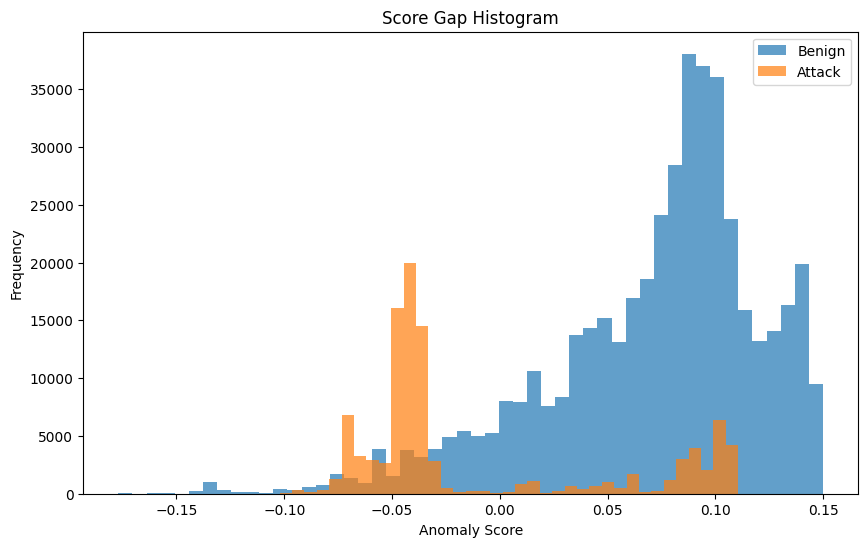

In [184]:
# Score Gap Histogram
plt.figure(figsize=(10,6))
plt.hist(
    anomaly_scores[y_test_binary == 1],
    bins=50,
    alpha=0.7,
    label="Benign"
)
plt.hist(
    anomaly_scores[y_test_binary == -1],
    bins=50,
    alpha=0.7,
    label="Attack"
)
plt.title("Score Gap Histogram")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()

plt.show()

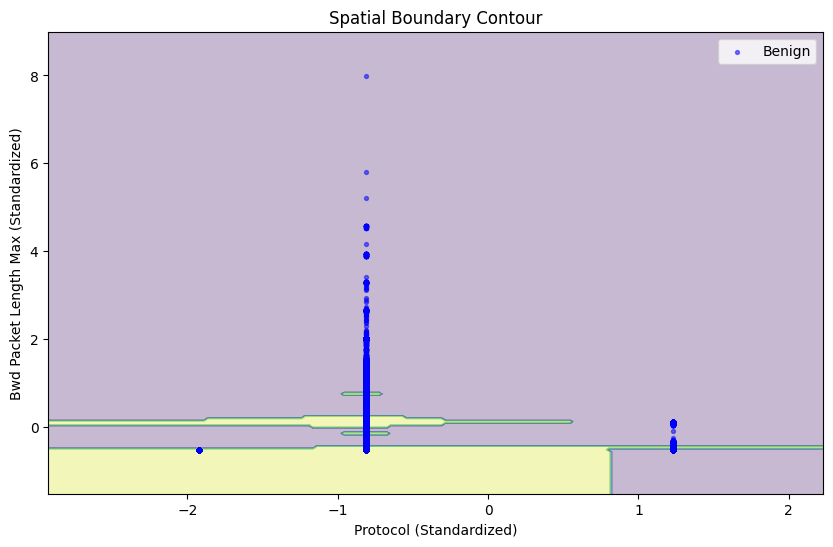

In [185]:
# Spatial Boundary Contour
# Use the first two standardized features
X_vis = X_train_benign.iloc[:, :2].values

# Train a new Isolation Forest on these two features only
iso_vis = IsolationForest(
    n_estimators=300,
    contamination=0.10,
    random_state=42,
    n_jobs=-1
)

iso_vis.fit(X_vis)

# Create a mesh grid
xx, yy = np.meshgrid(
    np.linspace(X_vis[:,0].min()-1, X_vis[:,0].max()+1, 200),
    np.linspace(X_vis[:,1].min()-1, X_vis[:,1].max()+1, 200)
)

Z = iso_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    s=8,
    c="blue",
    alpha=0.5,
    label="Benign"
)

plt.title("Spatial Boundary Contour")
plt.xlabel("Protocol (Standardized)")
plt.ylabel("Bwd Packet Length Max (Standardized)")
plt.legend()

plt.show()

In [186]:
#ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

# Calculating ROC Values

y_true = y_test.apply(lambda x: 0 if x == "Benign" else 1)

# Isolation Forest:
# Smaller score = More anomalous
scores = -iso_forest.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_true, scores)
auc = roc_auc_score(y_true, scores)

print("ROC AUC Score:", round(auc, 4))

ROC AUC Score: 0.8232


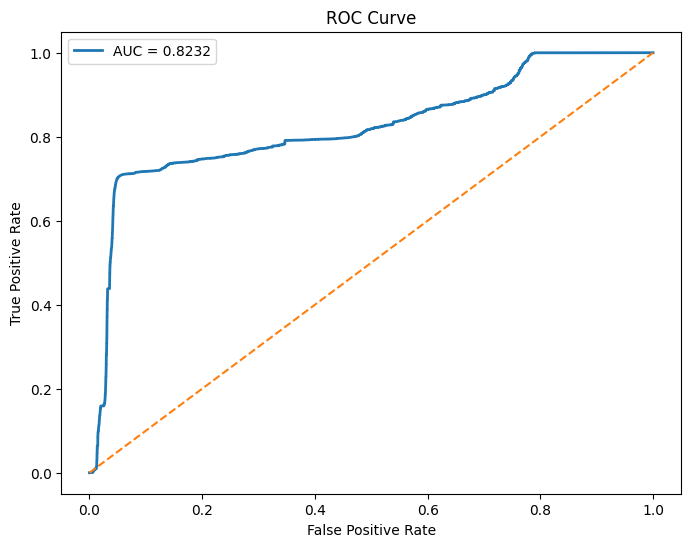

In [187]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr,
         linewidth=2,
         label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [188]:
#diagnosis
temp = pd.DataFrame({
    "True_Label": y_test.reset_index(drop=True),
    "Prediction": predictions
})

table = pd.crosstab(temp["True_Label"], temp["Prediction"])

print(table)

print("\nDetection Rate by Attack:\n")

for attack in table.index:
    if attack != "Benign":
        detected = table.loc[attack, -1] if -1 in table.columns else 0
        total = table.loc[attack].sum()
        print(f"{attack:15s}: {detected}/{total} ({detected/total:.2%})")

Prediction                     -1       1
True_Label                               
Benign                      45582  409964
Bot                            36     395
DDoS                        24226   14178
DoS GoldenEye                1605    1481
DoS Hulk                    46379    5475
DoS Slowhttptest               79    1489
DoS slowloris                  22    1594
FTP-Patator                     5    1774
Heartbleed                      3       0
Infiltration                    0      11
PortScan                       52     535
SSH-Patator                     2     964
Web Attack � Brute Force       12     429
Web Attack � Sql Injection      0       6
Web Attack � XSS                3     193

Detection Rate by Attack:

Bot            : 36/431 (8.35%)
DDoS           : 24226/38404 (63.08%)
DoS GoldenEye  : 1605/3086 (52.01%)
DoS Hulk       : 46379/51854 (89.44%)
DoS Slowhttptest: 79/1568 (5.04%)
DoS slowloris  : 22/1616 (1.36%)
FTP-Patator    : 5/1779 (0.28%)
Heartbleed     

In [189]:
contamination_values = [0.03, 0.05, 0.08, 0.10, 0.12, 0.15]

for c in contamination_values:

    print("="*60)
    print(f"Contamination = {c}")
    print("="*60)

    iso = IsolationForest(
        n_estimators=300,
        contamination=c,
        random_state=42,
        n_jobs=-1
    )

    iso.fit(X_train_benign)

    predictions = iso.predict(X_test)

    temp = pd.DataFrame({
        "True_Label": y_test.reset_index(drop=True),
        "Prediction": predictions
    })

    print(pd.crosstab(temp["True_Label"], temp["Prediction"]))

Contamination = 0.03
Prediction                     -1       1
True_Label                               
Benign                      12088  443458
Bot                            21     410
DDoS                        13138   25266
DoS GoldenEye                 162    2924
DoS Hulk                     2532   49322
DoS Slowhttptest                0    1568
DoS slowloris                   1    1615
FTP-Patator                     2    1777
Heartbleed                      3       0
Infiltration                    0      11
PortScan                       21     566
SSH-Patator                     0     966
Web Attack � Brute Force        2     439
Web Attack � Sql Injection      0       6
Web Attack � XSS                0     196
Contamination = 0.05
Prediction                     -1       1
True_Label                               
Benign                      22880  432666
Bot                            24     407
DDoS                        23677   14727
DoS GoldenEye                 820 

In [212]:
#Save isolation forest model
import joblib
joblib.dump(iso_forest, "isolation_forest.pkl")
print("Model saved successfully!")

Model saved successfully!


In [213]:
# Save the fitted StandardScaler
joblib.dump(scaler, "isolation_forest_scaler.pkl")

['isolation_forest_scaler.pkl']

In [214]:
# Save the selected features
joblib.dump(features, "selected_features.pkl")

['selected_features.pkl']